# Agentic forecasting step-by-step

**skforecast-ai** is an **AI forecasting assistant** that pairs a deterministic engine, powered by [**skforecast**](https://skforecast.org), with an **LLM reasoning layer**. Simply provide a time series, and the assistant automatically profiles the data, selects a model using established best practices, and evaluates its performance. It returns both the final forecast and the runnable skforecast script that produced it.

This tutorial walks through the **step-by-step path**: the approach for users who want granular control to inspect or adjust intermediate decisions before committing to a full run. If you prefer a single-call workflow that returns results immediately, see the [fast-path tutorial](./agentic-forecasting.html).

Both paths share the same deterministic engine and produce identical results and reproducible `skforecast` code. The step-by-step path gives you three additional capabilities:

+ **Inspect intermediate objects**: examine the `ForecastingProfile` and `ForecastPlan` before any model is trained, and confirm the assistant's recommendations make sense for your domain.

+ **Override any single decision**: change the estimator, lags, window features, or preprocessing without re-running the entire pipeline from scratch. Pass the modified plan directly to `forecast()` or `backtest()`.

+ **Reuse the profile and plan across branches**: build the profile and plan once, then run `forecast()` for future predictions, `backtest()` for historical evaluation, and `compare()` to rank several candidate configurations: each reusing the same profile, with no redundant profiling.

The `ask()` method is available at every stage. It interprets what you pass to it (a profile, a plan, a forecast result, a backtest result, or a comparison result), but it never executes the workflow or silently changes any recommendation.

<div style="box-sizing:border-box; margin:16px 0; font-family:-apple-system,Segoe UI,Roboto,Helvetica,Arial,sans-serif; color:#24292f; max-width:100%;">
  <div style="box-sizing:border-box; display:flex; gap:20px; flex-wrap:wrap; align-items:stretch;">

<!-- Fast path -->
<div style="box-sizing:border-box; flex:1 1 260px; min-width:0; border:1px solid #d0d7de; border-radius:12px; overflow:hidden; display:flex; flex-direction:column;">
    <div style="box-sizing:border-box; background:#0969da; color:#ffffff; padding:12px 16px; font-size:15px; font-weight:700;">Fast path: one call</div>
    <div style="box-sizing:border-box; padding:16px; background:#f6f8fa; flex:1;">
    <p style="margin:0 0 12px 0; font-size:13px;">Profiling, planning and execution happen internally.</p>
    <div style="box-sizing:border-box; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:10px 12px; text-align:center; font-weight:600;">data</div>
    <div style="text-align:center; color:#57606a; font-size:18px; line-height:1.4;">&#8595;</div>
    <div style="box-sizing:border-box; display:flex; gap:12px; flex-wrap:wrap;">
        <div style="box-sizing:border-box; flex:1 1 150px; min-width:0; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:10px;">
        <div style="font-size:11px; color:#57606a; text-transform:uppercase; letter-spacing:.5px; text-align:center; margin-bottom:6px;">Forecast</div>
        <div style="box-sizing:border-box; background:#dbeafe; border:1px solid #0969da; border-radius:8px; padding:8px; text-align:center; font-weight:700;">forecast()<br><span style="font-weight:400; font-size:12px; color:#57606a;">or forecast_code()</span></div>
        <div style="text-align:center; color:#57606a; font-size:15px; line-height:1.4;">&#8595;</div>
        <div style="text-align:center; font-size:12px; color:#24292f;">predictions + code</div>
        </div>
        <div style="box-sizing:border-box; flex:1 1 150px; min-width:0; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:10px;">
        <div style="font-size:11px; color:#57606a; text-transform:uppercase; letter-spacing:.5px; text-align:center; margin-bottom:6px;">Backtesting (validation)</div>
        <div style="box-sizing:border-box; background:#dbeafe; border:1px solid #0969da; border-radius:8px; padding:8px; text-align:center; font-weight:700;">create_cv()<br><span style="font-weight:400; font-size:12px; color:#57606a;">Deterministic, Agentic mode</span><br><span style="font-weight:400; font-size:12px; color:#57606a;">or pass a skforecast TimeSeriesFold object</span></div>
        <div style="text-align:center; color:#57606a; font-size:15px; line-height:1.4;">&#8595;</div>
        <div style="box-sizing:border-box; background:#dbeafe; border:1px solid #0969da; border-radius:8px; padding:8px; text-align:center; font-weight:700;">backtest()<br><span style="font-weight:400; font-size:12px; color:#57606a;">or backtest_code()</span></div>
        <div style="text-align:center; color:#57606a; font-size:15px; line-height:1.4;">&#8595;</div>
        <div style="text-align:center; font-size:12px; color:#24292f;">metrics + predictions + code</div>
        </div>
    </div>
    </div>
</div>

<!-- Step-by-step path -->
<div style="box-sizing:border-box; flex:1.6 1 340px; min-width:0; border:1px solid #d0d7de; border-radius:12px; overflow:hidden; display:flex; flex-direction:column;">
    <div style="box-sizing:border-box; background:#1a7f37; color:#ffffff; padding:12px 16px; font-size:15px; font-weight:700;">Step-by-step path: full control</div>
    <div style="box-sizing:border-box; padding:16px; background:#f6f8fa; flex:1;">
    <p style="margin:0 0 12px 0; font-size:13px;">Build a <code>profile</code> and a <code>plan</code> from your data, then branch into forecasting and backtesting.</p>
    <div style="box-sizing:border-box; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:8px 12px; text-align:center; font-weight:600;">data</div>
    <div style="text-align:center; color:#57606a; font-size:16px; line-height:1.4;">&#8595;</div>
    <div style="box-sizing:border-box; background:#dcfce7; border:1px solid #1a7f37; border-radius:8px; padding:8px 12px; text-align:center; font-weight:700;">profile()</div>
    <div style="text-align:center; color:#57606a; font-size:16px; line-height:1.4;">&#8595;</div>
    <div style="box-sizing:border-box; background:#dcfce7; border:1px solid #1a7f37; border-radius:8px; padding:8px 12px; text-align:center; font-weight:700;">plan()<br><span style="font-weight:400; font-size:12px; color:#57606a;">refine_plan(), optional (Deterministic or Agentic mode)</span></div>
    <div style="text-align:center; color:#57606a; font-size:16px; line-height:1.4;">&#8595;</div>
    <div style="box-sizing:border-box; display:flex; gap:12px; flex-wrap:wrap;">
        <div style="box-sizing:border-box; flex:1 1 150px; min-width:0; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:10px;">
        <div style="font-size:11px; color:#57606a; text-transform:uppercase; letter-spacing:.5px; text-align:center; margin-bottom:6px;">Forecast</div>
        <div style="box-sizing:border-box; background:#dcfce7; border:1px solid #1a7f37; border-radius:8px; padding:8px; text-align:center; font-weight:700;">forecast()<br><span style="font-weight:400; font-size:12px; color:#57606a;">or forecast_code()</span></div>
        <div style="text-align:center; color:#57606a; font-size:15px; line-height:1.4;">&#8595;</div>
        <div style="text-align:center; font-size:12px; color:#24292f;">predictions + code</div>
        </div>
        <div style="box-sizing:border-box; flex:1 1 150px; min-width:0; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:10px;">
        <div style="font-size:11px; color:#57606a; text-transform:uppercase; letter-spacing:.5px; text-align:center; margin-bottom:6px;">Backtesting (validation)</div>
        <div style="box-sizing:border-box; background:#dcfce7; border:1px solid #1a7f37; border-radius:8px; padding:8px; text-align:center; font-weight:700;">create_cv()<br><span style="font-weight:400; font-size:12px; color:#57606a;">Deterministic, Agentic mode</span><br><span style="font-weight:400; font-size:12px; color:#57606a;">or pass a skforecast TimeSeriesFold object</span></div>
        <div style="text-align:center; color:#57606a; font-size:15px; line-height:1.4;">&#8595;</div>
        <div style="box-sizing:border-box; background:#dcfce7; border:1px solid #1a7f37; border-radius:8px; padding:8px; text-align:center; font-weight:700;">backtest()<br><span style="font-weight:400; font-size:12px; color:#57606a;">or backtest_code()</span></div>
        <div style="text-align:center; color:#57606a; font-size:15px; line-height:1.4;">&#8595;</div>
        <div style="text-align:center; font-size:12px; color:#24292f;">metrics + predictions + code</div>
        </div>
    </div>
    </div>
</div>

</div>

  <!-- compare() banner -->
  <div style="box-sizing:border-box; margin-top:16px; border:1px solid #bc4c00; border-radius:12px; overflow:hidden;">
    <div style="box-sizing:border-box; background:#bc4c00; color:#ffffff; padding:10px 16px; font-size:15px; font-weight:700;">Model selection: which forecaster should you use?</div>
    <div style="box-sizing:border-box; padding:12px 16px; background:#fff4ed; font-size:13px;">
      <p style="margin:0 0 12px 0;"><code>compare()</code> answers the question every forecasting project starts with: <b>Among several reasonable models, which one actually performs best on my data?</b> Every candidate is evaluated using the same data and cross-validation strategy. Therefore, the differences you see come from the models, not from the setup.</p>
      <table style="width:100%; border:0; border-collapse:collapse; table-layout:fixed; background:transparent; box-shadow:none; margin:0;">
        <tbody style="border:0; background:transparent;">
        <tr style="border:0; background:transparent;">
          <td style="width:28%; border:0; background:transparent; vertical-align:middle; padding:0;">
            <div style="box-sizing:border-box; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:10px 12px; text-align:center; font-size:13px;"><span style="font-weight:600;">Candidates</span><br><span style="font-size:12px; color:#57606a;">A handful of configurations worth testing: different forecasters, estimators, lags or window features. Supply your own, or let the data profile propose them.</span></div>
          </td>
          <td style="width:5%; border:0; background:transparent; vertical-align:middle; text-align:center; color:#57606a; font-size:18px; padding:0;">&#8594;</td>
          <td style="width:34%; border:0; background:transparent; vertical-align:middle; padding:0;">
            <div style="box-sizing:border-box; background:#ffe0cc; border:1px solid #bc4c00; border-radius:8px; padding:10px 12px; text-align:center; font-size:13px;"><span style="font-weight:700;">compare()</span><br><span style="font-size:12px; color:#57606a;">Runs a full backtest for each candidate under identical conditions, and scores them with the metrics you care about.</span></div>
          </td>
          <td style="width:5%; border:0; background:transparent; vertical-align:middle; text-align:center; color:#57606a; font-size:18px; padding:0;">&#8594;</td>
          <td style="width:28%; border:0; background:transparent; vertical-align:middle; padding:0;">
            <div style="box-sizing:border-box; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:10px 12px; text-align:center; font-size:13px;"><span style="font-weight:600;">A ranked answer</span><br><span style="font-size:12px; color:#57606a;">A leaderboard sorted best to worst, the reproducible code behind every row, and the winner ready to be used for forecasting or further tuning.</span></div>
          </td>
        </tr>
        </tbody>
      </table>
      <p style="margin:12px 0 0 0; font-size:12px; color:#57606a; text-align:center;">The ranking is a plain sort of the metric column: fully deterministic and auditable. The LLM plays no part in choosing the winner.</p>
    </div>
  </div>

  <!-- ask() banner -->
  <div style="box-sizing:border-box; margin-top:16px; border:1px solid #8250df; border-radius:12px; overflow:hidden;">
    <div style="box-sizing:border-box; background:#8250df; color:#ffffff; padding:10px 16px; font-size:15px; font-weight:700;">LLM reasoning: available at any moment, in any workflow</div>
    <div style="box-sizing:border-box; padding:12px 16px; background:#faf5ff; font-size:13px;">Call <code>ask()</code> before, during or after either path. It can take a <code>profile</code>, a <code>plan</code>, a <code>result</code> (from <code>forecast()</code>, <code>backtest()</code> or <code>compare()</code>), or nothing at all (pure Q&amp;A).</div>
  </div>
</div>

The following example walks through the **step-by-step** allowing user to understand and control what happens under the hood. If you prefer the quickest way to go from raw data to a validated forecast with minimal setup, visit the [fast-path tutorial](./agentic-forecasting.html).

## Assistant initialization

The first step is to instantiate a `ForecastingAssistant`, which will be responsible for executing the entire workflow (profiling, planning, backtesting, and forecasting), as well as explaining the outputs and suggesting improvements.

To activate the optional LLM support, users must pass a string in the format `'provider:model_name'` (for example, `'openai:gpt-5.5'`, `'google:gemini-3-flash-preview'`, `'anthropic:claude-sonnet-5'`, or `'ollama:qwen3:8b'`). For hosted providers, the corresponding API key must be available as an environment variable or passed explicitly when creating the assistant. In this tutorial, we set `send_data_to_llm=False`. This ensures strict data privacy: the LLM receives only metadata and summary statistics, never the raw time series values.

In [1]:
# Data processing
# ==============================================================================
import os
import pandas as pd
from skforecast.datasets import fetch_dataset

# Plots
# ==============================================================================
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import plotly.offline as poff
pio.templates.default = "seaborn"
poff.init_notebook_mode(connected=True)
plt.style.use('seaborn-v0_8-darkgrid')

# skforecast and skforecast-ai
# ==============================================================================
import skforecast
import skforecast_ai
from skforecast_ai import ForecastingAssistant
from skforecast.model_selection import TimeSeriesFold
from skforecast.plot import set_dark_theme

# Python utilities
# ==============================================================================
import textwrap

color = '\033[1m\033[38;5;208m'
print(f"{color}Version skforecast_ai: {skforecast_ai.__version__}")
print(f"{color}Version skforecast: {skforecast.__version__}")

Version skforecast_ai: 0.2.0
Version skforecast: 0.23.0


<div class="admonition note" name="html-admonition" style="background: rgba(0,184,212,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00b8d4; border-color: #00b8d4; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00b8d4;"></i>
    <b style="color: #00b8d4;">✏️ Note</b>
</p>

  <p>
    If you do not have access to an LLM, you can still follow the full tutorial using only the deterministic methods. Profiling, planning, backtesting, and forecasting all run without an LLM. Only the <code>ask()</code> explanations and the LLM-guided variants of <code>refine_plan()</code> and <code>create_cv()</code> require a configured LLM; their deterministic counterparts work without one.
  </p>

</div>

In [2]:
# LLM-enabled assistant
# ==============================================================================
LLM_MODEL = "google:gemini-3.5-flash"
api_key = os.getenv("GOOGLE_API_KEY")

assistant = ForecastingAssistant(
    llm=LLM_MODEL, api_key=api_key, send_data_to_llm=False
)

# Using AWS Bedrock
# ==============================================================================
# assistant = ForecastingAssistant(
#     llm='bedrock:eu.anthropic.claude-sonnet-4-6',
#     base_url="eu-west-1"
# )

# Assistant without LLM (deterministic only)
# ==============================================================================
# assistant = ForecastingAssistant()

<div role="alert" style="background: rgba(255,145,0,.08); border-left: 6px solid #ff9100; border-radius: 6px; padding: 10px 12px; margin: 1em 0;">

<p style="display:flex; align-items:center; font-size:1rem; color:#ff9100; margin:0 0 6px 0; font-weight:600;">
    <span style="margin-right:6px; font-size:18px;">⚠️</span>
    <strong style="margin-right:6px; font-size:18px;">Your data stays private</strong>
</p>

<p>
By default, enabling an LLM does not send your time-series data to the model provider.
The assistant passes only summary statistics, detected frequency,
seasonality flags and the forecaster configuration, never the raw observations.
To explicitly allow it, pass <code>send_data_to_llm=True</code>.
</p>

</div>

## Data

The data used in this tutorial represent the hourly usage of the bike share system in the city of Washington, D.C. during the years 2011 and 2012. In addition to the number of users per hour, information about weather conditions and holidays is available.

In [3]:
# Downloading data
# ==============================================================================
data = fetch_dataset('bike_sharing', raw=True)
data = data[['date_time', 'users', 'holiday', 'weather', 'temp']]
data['date_time'] = pd.to_datetime(data['date_time'])
data.head()

╭───────────────────────────────── bike_sharing ──────────────────────────────────╮
│ Description:                                                                    │
│ Hourly usage of the bike share system in the city of Washington D.C. during the │
│ years 2011 and 2012. In addition to the number of users per hour, information   │
│ about weather conditions and holidays is available.                             │
│                                                                                 │
│ Source:                                                                         │
│ Fanaee-T,Hadi. (2013). Bike Sharing Dataset. UCI Machine Learning Repository.   │
│ https://doi.org/10.24432/C5W894.                                                │
│                                                                                 │
│ URL:                                                                            │
│ https://raw.githubusercontent.com/skforecast/skforecast-                        │
│ datasets/main/data/bike_sharing_dataset_clean.csv                               │
│                                                                                 │
│ Shape: 17544 rows x 12 columns                                                  │
╰─────────────────────────────────────────────────────────────────────────────────╯

,date_time,users,holiday,weather,temp
0,2011-01-01 00:00:00,16.0,0.0,clear,9.84
1,2011-01-01 01:00:00,40.0,0.0,clear,9.02
2,2011-01-01 02:00:00,32.0,0.0,clear,9.02
3,2011-01-01 03:00:00,13.0,0.0,clear,9.84
4,2011-01-01 04:00:00,1.0,0.0,clear,9.84


<div class="admonition note" name="html-admonition" style="background: rgba(0,184,212,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00b8d4; border-color: #00b8d4; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00b8d4;"></i>
    <b style="color: #00b8d4;">✏️ Note</b>
</p>

  <p>
    <code>skforecast-ai</code> is ready to preprocess the data, but it is recommended that users apply their own preprocessing steps before using the assistant. This ensures the data is in the desired format and any necessary transformations have been applied before proceeding with the forecasting workflow.
  </p>

</div>

In [4]:
# Interactive plot of time series
# ==============================================================================
fig = go.Figure()
fig.add_trace(
    go.Scatter(x=data['date_time'], y=data['users'], mode='lines', name='Users')
)
fig.update_layout(
    title  = 'Number of users',
    xaxis_title="Time",
    yaxis_title="Users",
    width=800,
    height=400,
    margin=dict(l=20, r=20, t=35, b=20),
    legend=dict(orientation="h", yanchor="top", y=1, xanchor="left", x=0.001)
)
fig.show()

For a deeper walkthrough of the exploratory analysis behind this dataset, see the skforecast example: [Forecasting time series with skforecast, XGBoost, LightGBM and CatBoost](https://cienciadedatos.net/documentos/py39-forecasting-time-series-with-skforecast-xgboost-lightgbm-catboost#Data_exploration).

## Profile the data

The `profile()` method is the first stage of the step-by-step workflow. It inspects the dataset and returns a `ForecastingProfile` object that contains:

+ **Data metadata**: detected frequency, index type, series lengths, missing values, and exogenous column roles.

+ **Modeling recommendations**: the selected forecaster family and estimator, along with alternative candidates and the reasoning behind each choice.

+ **Lag structure**: PACF-significant lags per series, used as a baseline for the planning stage.

+ **Window feature suggestions**: rolling statistics configurations appropriate for the detected seasonality.

This is a purely deterministic step: no LLM is involved. The `profile` object is a prerequisite for both `plan()` and `ask()` explain mode.

| Attribute | Description |
|---|---|
| `data_profile` | Full dataset metadata: frequency, index type, series lengths, missing values, exog columns |
| `forecaster` | Recommended skforecast forecaster class name |
| `forecaster_candidates` | Ordered list of compatible forecaster names |
| `estimator` | Recommended estimator class name (None for statistical models) |
| `estimator_candidates` | Ordered list of compatible estimator names |
| `series_pacf` | Per-series PACF-significant lags (used by `plan()` to set default lags) |
| `window_features` | Suggested window feature configurations |
| `calendar_features` | Recommended calendar feature names based on detected seasonality |
| `explanation` | Human-readable explanation of why this forecaster and estimator were selected |

In [5]:
# Profile the data
# ==============================================================================
profile = assistant.profile(
    data        = data,
    target      = 'users',
    date_column = 'date_time'
)

In [6]:
# Inspect the profile
# ==============================================================================
profile

                          Dataset Profile                          
┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property       ┃ Value                                          ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Format         │ single                                         │
├────────────────┼────────────────────────────────────────────────┤
│ Series         │ 1                                              │
├────────────────┼────────────────────────────────────────────────┤
│ Observations   │ 17544                                          │
├────────────────┼────────────────────────────────────────────────┤
│ Frequency      │ h                                              │
├────────────────┼────────────────────────────────────────────────┤
│ Target         │ users                                          │
├────────────────┼────────────────────────────────────────────────┤
│ Exog columns   │ holiday, weather, temp  (categorical: weather) │
├────────────────┼────────────────────────────────────────────────┤
│ Missing values │ None                                           │
└────────────────┴────────────────────────────────────────────────┘

                                    Recommendation                                     
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property              ┃ Value                                                       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Task type             │ single_series                                               │
├───────────────────────┼─────────────────────────────────────────────────────────────┤
│ Forecaster            │ ForecasterRecursive                                         │
├───────────────────────┼─────────────────────────────────────────────────────────────┤
│ Forecaster candidates │ ForecasterRecursive, ForecasterDirect, ForecasterFoundation │
├───────────────────────┼─────────────────────────────────────────────────────────────┤
│ Estimator             │ LGBMRegressor                                               │
├───────────────────────┼─────────────────────────────────────────────────────────────┤
│ Estimator candidates  │ LGBMRegressor, XGBRegressor, Ridge                          │
└───────────────────────┴─────────────────────────────────────────────────────────────┘

╭───────────────────────────────── Profile Explanation ──────────────────────────────────╮
│                                                                                        │
│  A single-series ML forecaster (ForecasterRecursive) is recommended. Data: 17544       │
│  observations, 'h' frequency. Alternative forecasters: ['ForecasterDirect',            │
│  'ForecasterFoundation']. Estimator: LGBMRegressor. A gradient boosting model is       │
│  preferred for a dataset of this size (17544 observations). Alternative estimators:    │
│  ['XGBRegressor', 'Ridge']. 3 exogenous variables (1 categorical) available as         │
│  predictors.                                                                           │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯

Once you have a profile, you can pass it to `ask()` to get an LLM-generated explanation of the modeling decisions. Note that the pre-computed `profile` is passed directly, so no profiling work is repeated.

In [7]:
# Ask the assistant to explain the profile
# ==============================================================================
answer = assistant.ask(
    prompt  = (
        "Explain why this forecaster and estimator were recommended for my "
        "hourly bike-sharing demand data, and what the exogenous variables add."
    ),
    profile = profile,
    steps   = 36,
)
answer.show_explanation()

╭────────────────────────────────── Assistant Response ──────────────────────────────────╮
│                                                                                        │
│  A single-series ForecasterRecursive with an LGBMRegressor estimator is recommended    │
│  because your dataset contains 17544 hourly observations of a single target variable,  │
│  users. A gradient boosting model like LGBMRegressor is well-suited for a dataset of   │
│  this size, and the recursive strategy efficiently generates the requested 36 steps    │
│  of forecasts. The exogenous variables, holiday, weather, and temp, provide            │
│  additional context that may contribute to explaining changes in hourly bike-sharing   │
│  demand.                                                                               │
│                                                                                        │
│  Why the Forecaster and Estimator Were Chosen                                          │
│                                                                                        │
│   • Single-Series Focus: The dataset consists of 1 target series, users, containing    │
│     17544 observations at an hourly frequency. A single-series machine learning        │
│     forecaster like ForecasterRecursive is the standard configuration for this setup.  │
│   • Alternative Forecasters: While ForecasterRecursive was selected, alternative       │
│     forecasters such as ForecasterDirect and ForecasterFoundation are also             │
│     applicable.                                                                        │
│   • Scalable Estimator: LGBMRegressor is a gradient boosting model preferred for a     │
│     dataset containing 17544 observations due to its efficiency and scaling.           │
│   • Alternative Estimators: Alternative estimators for this plan include XGBRegressor  │
│     and Ridge.                                                                         │
│   • Missing Value Handling: The plan keeps NaN rows because LGBMRegressor is a         │
│     NaN-tolerant estimator.                                                            │
│                                                                                        │
│  The Role of Exogenous and Calendar Features                                           │
│                                                                                        │
│   • Predictors: The strategy incorporates 3 exogenous variables: holiday, weather,     │
│     and temp. These external factors are associated with hourly bike-sharing           │
│     patterns.                                                                          │
│   • Categorical Handling: The weather column is detected as a categorical exogenous    │
│     variable and is handled automatically by skforecast using the                      │
│     categorical_features='auto' setting.                                               │
│   • Calendar Context: The plan extracts calendar features, specifically hour,          │
│     day_of_week, weekend, and month, using raw ordinal encoding to capture temporal    │
│     cycles.                                                                            │
│   • Historic Dynamics: The forecaster uses 32 specific lags, ranging from lag 1 up to  │
│     lag 337, alongside rolling window features such as mean and standard deviation     │
│     over windows of 3, 24, and 168 hours to capture short-term and weekly trends.      │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯

## Build the plan

The `plan()` method converts the coarse modeling decisions in the `ForecastingProfile` into a fully-specified, executable configuration. It determines:

+ **Lags**: derived from the PACF-significant lags detected in the profile. You can override these explicitly.
+ **Window features**: rolling statistics configurations appropriate for the detected seasonality.
+ **Preprocessing steps**: ordered list of transformations (e.g., differencing, scaling, NaN handling).
+ **Prediction interval method**: `'bootstrapping'`, `'conformal'`, or `'native'` (selected based on the estimator).
+ **Metrics**: the primary and secondary evaluation metrics.

Like `profile()`, this is a deterministic step. The resulting `ForecastPlan` object is the complete blueprint that `forecast()` and `backtest()` execute.

| Attribute | Description |
|---|---|
| `forecaster` | Forecaster class name |
| `estimator` | Estimator class name |
| `forecaster_kwargs` | All constructor kwargs for the forecaster, including `lags` and `window_features` |
| `estimator_kwargs` | Constructor kwargs for the estimator |
| `steps` | Forecast horizon |
| `interval` | Prediction interval quantiles, e.g. `[0.1, 0.9]` |
| `interval_method` | Method used to produce the interval (`bootstrapping`, `conformal`, or `native`) |
| `use_exog` | Whether exogenous variables are included |
| `preprocessing_steps` | Ordered list of preprocessing actions with code snippets |
| `explanation` | Human-readable explanation of plan decisions |

In [8]:
# Build a plan from the profile
# ==============================================================================
plan = assistant.plan(
    profile  = profile,
    steps    = 36,
    interval = [0.1, 0.9]  # 80% prediction interval
)

In [9]:
# Inspect the plan
# ==============================================================================
plan

                                      Forecast Plan                                       
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property          ┃ Value                                                              ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Task type         │ single_series                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Forecaster        │ ForecasterRecursive                                                │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Estimator         │ LGBMRegressor                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Steps             │ 36                                                                 │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Frequency         │ h                                                                  │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Lags              │ [1, 2, 3, 5, 8, 10, 15, 17, 19, 20, 21, 22, 23, 24, 25, 26, 32,    │
│                   │ 33, 119, 121, 135, 136, 142, 143, 145, 160, 166, 167, 169, 313,    │
│                   │ 335, 337]                                                          │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Window features   │ [{'stats': ['mean', 'std'], 'window_size': 3}, {'stats': ['mean'], │
│                   │ 'window_size': 24}, {'stats': ['mean'], 'window_size': 168}]       │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Calendar features │ ['hour', 'day_of_week', 'weekend', 'month'] (raw ordinal encoding) │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Use exog          │ True                                                               │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Interval          │ [0.1, 0.9]                                                         │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Interval method   │ bootstrapping                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Primary metric    │ mean_absolute_error                                                │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Preprocessing     │ 1 step                                                             │
└───────────────────┴────────────────────────────────────────────────────────────────────┘

                                   Preprocessing Steps                                    
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Step                    ┃ Reason                                                       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ handle_categorical_exog │ Categorical exogenous variables detected: ['weather']. These │
│                         │ are handled automatically by skforecast                      │
│                         │ (categorical_features='auto').                               │
└─────────────────────────┴──────────────────────────────────────────────────────────────┘

╭─────────────────────────────────── Plan Explanation ───────────────────────────────────╮
│                                                                                        │
│  Plan: ForecasterRecursive + LGBMRegressor. Lags: [1, 2, 3, 5, 8, 10, 15, 17, 19, 2

Pass both the `profile` and the `plan` to `ask()` for a detailed explanation of the chosen configuration.

In [10]:
# Ask the assistant to explain the plan
# ==============================================================================
answer = assistant.ask(
    prompt  = (
        "Walk me through this plan. Why these lags and window features, "
        "and how will the 80% prediction interval be produced?"
    ),
    profile = profile,
    plan    = plan,
)
answer.show_explanation()

╭────────────────────────────────── Assistant Response ──────────────────────────────────╮
│                                                                                        │
│  This forecasting plan utilizes a recursive machine learning forecaster paired with a  │
│  LightGBM regressor to predict hourly user demand over a 36-hour horizon. The          │
│  strategy integrates historical lags, multi-scale rolling window features, calendar    │
│  variables, and exogenous indicators to capture complex patterns in the dataset's      │
│  17,544 observations. Uncertainty is quantified using an 80 percent prediction         │
│  interval generated via residual bootstrapping.                                        │
│                                                                                        │
│  Lags and Window Features Strategy                                                     │
│                                                                                        │
│   • Lags selection: The selected lags include immediate hourly steps (such as 1, 2,    │
│     and 3) to capture short-term momentum. It also spans daily markers (around lag     │
│     24) and extended weekly indicators (extending up to lag 337) to capture repeating  │
│     daily and weekly cycles.                                                           │
│   • Short-term window features: A rolling window of size 3 calculates the local mean   │
│     and standard deviation, allowing the model to quickly adapt to sudden changes in   │
│     volatility or target level.                                                        │
│   • Mid-term window features: A rolling window of size 24 calculates a daily average,  │
│     helping smooth out hourly noise and establish a baseline for the current day.      │
│   • Long-term window features: A rolling window of size 168 captures the average       │
│     level of the entire preceding week, which acts as a broader baseline for user      │
│     behavior.                                                                          │
│                                                                                        │
│  Generating the 80 Percent Prediction Interval                                         │
│                                                                                        │
│   • Nominal coverage: The requested interval is [0.1, 0.9], which defines the lower    │
│     and upper bounds corresponding to the 10th and 90th quantiles, yielding an 80      │
│     percent coverage level.                                                            │
│   • Bootstrapping method: This interval is produced by resampling the model's          │
│     training residuals. When making future predictions, the forecaster runs multiple   │
│     simulations where it randomly samples from these stored errors and adds them back  │
│     to the recursive steps.                                                            │
│   • Bounds calculation: From these simulated forecast paths, the system extracts the   │
│     0.1 and 0.9 quantiles at each of the 36 steps to build the final uncertainty       │
│     limits around the point forecast.                                                  │
│                                                                                        │
│  Integrating Exogenous and Calendar Predictors                                         │
│                                                                                        │
│   • Exogenous variables: The model incorporates external drivers including holiday,    │
│     weather, and temp. The categorical weather column is automatically encoded         │
│     internally using the automatic categorical features handler.                       │
│   • Calendar features: The datetime index is used to automatically extract hour,       │
│     day_of_week, weekend, and month as raw ordinal integer features to help the      

## Refine the plan (optional)

The `refine_plan()` method lets you adjust the plan before execution. It operates in two distinct modes:

+ **Deterministic mode** (`prompt=None`): pass explicit configuration overrides such as `lags`, `estimator`, `estimator_kwargs`, `forecaster`, `steps`, `interval`, or `window_features`. Only the fields you explicitly specify are updated; the rest of the configuration is deterministically re-derived from the original plan.

+ **LLM mode** (`prompt` provided): describe your domain knowledge in natural language. The LLM interprets this context and suggests appropriate `lags` and `window_features`. Its reasoning is appended to `plan.explanation` and the changed fields are recorded in `plan.llm_refined_fields` for full traceability.

<div class="admonition note" name="html-admonition" style="background: rgba(255,145,0,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #ff9100; border-color: #ff9100; padding-left: 10px; padding-right: 10px">

<p class="title">
    <i style="font-size: 18px; color:#ff9100; border-color: #ff1744;"></i>
    <b style="color: #ff9100;"> <span style="color: #ff9100;">&#9888;</span> Warning</b>
</p>

<p>A refined plan is a <strong>hypothesis, not a guaranteed improvement</strong>. The LLM may propose lags or window features that are not helpful for the series, or it may misread the domain context you provided. Always compare the refined plan against the original baseline using a proper backtest over multiple folds before adopting it.</p>

</div>

### Deterministic mode

In [11]:
# Refine the plan with explicit overrides (no LLM required)
# ==============================================================================
plan_det = assistant.refine_plan(
    profile          = profile,
    plan             = plan,
    lags             = [1, 2, 3, 24, 48, 168],
    estimator_kwargs = {'n_estimators': 200, 'max_depth': 6}
)
plan_det

                                      Forecast Plan                                       
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property          ┃ Value                                                              ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Task type         │ single_series                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Forecaster        │ ForecasterRecursive                                                │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Estimator         │ LGBMRegressor                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Steps             │ 36                                                                 │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Frequency         │ h                                                                  │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Lags              │ [1, 2, 3, 24, 48, 168]                                             │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Window features   │ [{'stats': ['mean', 'std'], 'window_size': 3}, {'stats': ['mean'], │
│                   │ 'window_size': 24}, {'stats': ['mean'], 'window_size': 168}]       │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Calendar features │ ['hour', 'day_of_week', 'weekend', 'month'] (raw ordinal encoding) │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Use exog          │ True                                                               │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Interval          │ [0.1, 0.9]                                                         │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Interval method   │ bootstrapping                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Primary metric    │ mean_absolute_error                                                │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Preprocessing     │ 1 step                                                             │
└───────────────────┴────────────────────────────────────────────────────────────────────┘

                                   Preprocessing Steps                                    
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Step                    ┃ Reason                                                       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ handle_categorical_exog │ Categorical exogenous variables detected: ['weather']. These │
│                         │ are handled automatically by skforecast                      │
│                         │ (categorical_features='auto').                               │
└─────────────────────────┴──────────────────────────────────────────────────────────────┘

╭─────────────────────────────────── Plan Explanation ───────────────────────────────────╮
│                                                                                        │
│  Plan: ForecasterRecursive + LGBMRegressor. Lags: [1, 2, 3, 24, 48, 168]. Window       │
│  features: ['mean(window=3)', 'std(window=3)', 'mean(window=24)',                      │
│  'mean(window=168)']. Calendar features: ['hour', 'day_of_week', 'weekend', 'month'

### LLM mode

In [12]:
# Refine the plan using LLM-guided domain knowledge
# ==============================================================================
prompt = (
    "I'm forecasting hourly bike rentals. Demand follows a clear daily rhythm with "
    "rush-hour peaks, and it changes between weekdays and weekends. It's also usually "
    "similar to what happened at the same time last week, and the last few hours give "
    "a good sense of the current trend. Please pick lags and rolling features that fit this."
)

plan_refined = assistant.refine_plan(
    profile = profile,
    plan    = plan,
    prompt  = prompt
)

In [13]:
# Refined plan proposed by the assistant
# ==============================================================================
plan_refined

                                      Forecast Plan                                       
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property          ┃ Value                                                              ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Task type         │ single_series                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Forecaster        │ ForecasterRecursive                                                │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Estimator         │ LGBMRegressor                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Steps             │ 36                                                                 │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Frequency         │ h                                                                  │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Lags              │ [1, 2, 3, 4, 5, 6, 24, 25, 168, 169]  (LLM-suggested)              │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Window features   │ [{'stats': ['mean', 'std'], 'window_size': 6}, {'stats': ['mean',  │
│                   │ 'std'], 'window_size': 24}, {'stats': ['mean'], 'window_size':     │
│                   │ 168}]  (LLM-suggested)                                             │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Calendar features │ ['hour', 'day_of_week', 'weekend', 'month'] (raw ordinal encoding) │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Use exog          │ True                                                               │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Interval          │ [0.1, 0.9]                                                         │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Interval method   │ bootstrapping                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Primary metric    │ mean_absolute_error                                                │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Preprocessing     │ 1 step                                                             │
└───────────────────┴────────────────────────────────────────────────────────────────────┘

                                   Preprocessing Steps                                    
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Step                    ┃ Reason                                                       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ handle_categorical_exog │ Categorical exogenous variables detected: ['weather']. These │
│                         │ are handled automatically by skforecast                      │
│                         │ (categorical_features='auto').                               │
└─────────────────────────┴──────────────────────────────────────────────────────────────┘

╭─────────────────────────────────── Plan Explanation ───────────────────────────────────╮
│                                                                                        │
│  Plan: ForecasterRecursive + LGBMRegressor. Lags: [1, 2, 3, 4, 5, 6, 24, 25, 168,      │
│  169]. Window features: ['mean(window=6)', 'std(window=6)', 'mean(window=24)',     

### Explain mode (refined plan)

In [14]:
# Ask the assistant what changed and why
# ==============================================================================
answer = assistant.ask(
    prompt  = (
        "What changed in the refined plan compared to the original, "
        "and why does it matter for this dataset?"
    ),
    profile = profile,
    plan    = plan_refined,
)
answer.show_explanation()

╭────────────────────────────────── Assistant Response ──────────────────────────────────╮
│                                                                                        │
│  The refined plan configures specific lags, rolling window features, and calendar      │
│  indicators to address the multi-scale temporal patterns in the hourly user dataset.   │
│  These features are designed to help the gradient boosting model capture short-term    │
│  momentum, daily cycles, and weekly rhythms. Note that these LLM-suggested             │
│  configurations are hypotheses rather than validated improvements, and any expected    │
│  accuracy gains should be confirmed via backtesting before relying on them.            │
│                                                                                        │
│  Key Changes in the Refined Plan                                                       │
│                                                                                        │
│   • Recent Trend Features: The plan introduces consecutive lags from 1 to 6 hours,     │
│     alongside a 6-hour rolling window that calculates both the mean and standard       │
│     deviation. These features are intended to capture immediate momentum and           │
│     short-term volatility in user activity.                                            │
│   • Daily Rhythm Features: The plan incorporates lags 24 and 25, paired with a         │
│     24-hour rolling window that tracks the mean and standard deviation. This           │
│     structure is designed to represent the 24-hour daily cycle and capture repeating   │
│     daily peaks.                                                                       │
│   • Weekly Pattern Features: To address same-day-last-week behavior, the plan adds     │
│     lags 168 and 169 (corresponding to 7 days ago) along with a 168-hour rolling       │
│     mean. This helps the model distinguish overall level differences between weekdays  │
│     and weekends.                                                                      │
│   • Calendar and Exogenous Inputs: The model incorporates raw ordinal calendar         │
│     features (hour, day of week, weekend, and month) alongside the provided exogenous  │
│     variables (holiday, weather, and temp).                                            │
│                                                                                        │
│  Why This Matters for the Dataset                                                      │
│                                                                                        │
│  The dataset consists of 17544 hourly observations of a single "users" target. For     │
│  hourly demand or usage data, behavior is highly dependent on the time of day and the  │
│  day of the week.                                                                      │
│                                                                                        │
│  Using a standard recursive forecaster with only immediate lags might cause the model  │
│  to lose track of daily and weekly cycles over the 36-step forecast horizon. By        │
│  explicitly building features for 6-hour, 24-hour, and 168-hour windows, the           │
│  LGBMRegressor is provided with direct historical context. This allows the model to    │
│  associate its predictions with both recent hourly trends and broader calendar-driven  │
│  cycles, such as distinguishing a Saturday afternoon from a Tuesday morning.           │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯

## Forecast

Once you have a `profile` and a `plan`, you can call `forecast()` or `forecast_code()`. Both accept the pre-computed `profile` and `plan` so no additional profiling is performed. The `forecast()` method executes the generated script and returns a `ForecastResult`; `forecast_code()` generates the script only, without running it.

The forecast branch operates in two modes:

+ **Evaluation mode** (`test_size` is set): the dataset is split into train and test sets, the model is trained on the train portion, and predictions are compared against the held-out actuals to compute metrics.

+ **Prediction mode** (`test_size=None`, the default): the model is trained on the entire dataset and forecasts the next `steps` time points into the future. Because there is no ground truth, no metrics are returned. If the data has exogenous variables, their future values must be supplied via `exog`.

### Evaluation mode

In [15]:
# Forecast in evaluation mode, reusing the pre-computed profile and plan
# ==============================================================================
results_eval = assistant.forecast(
    data        = data,
    target      = 'users',
    date_column = 'date_time',
    steps       = 36,
    interval    = [0.1, 0.9],   # 80% prediction interval
    test_size   = 36,           # Last 36 hours as test set
    profile     = profile,      # Reuse the pre-computed profile
    plan        = plan_refined  # Reuse the refined plan
)

display(results_eval.metrics)
display(results_eval.predictions.head())

╭─────────────────────────────── IgnoredArgumentWarning ───────────────────────────────╮
│ A pre-built `plan` was provided, so the following argument(s) are ignored:           │
│ ['interval']. To change these, refine the plan with `refine_plan()` before calling.  │
│                                                                                      │
│ Category : skforecast.exceptions.IgnoredArgumentWarning                              │
│ Location :                                                                           │
│ /opt/homebrew/Caskroom/miniconda/base/envs/skforecast_ai_py13/lib/python3.13/site-pa │
│ ckages/skforecast_ai/_utils.py:402                                                   │
│ Suppress : warnings.simplefilter('ignore', category=IgnoredArgumentWarning)          │
╰──────────────────────────────────────────────────────────────────────────────────────╯

,series,MAE,MSE,MASE,MAPE
0,users,37.133737,3493.960695,0.576707,0.406163


,pred,lower_bound,upper_bound
2012-12-30 12:00:00,146.388405,109.552794,173.692839
2012-12-30 13:00:00,140.477726,105.349660,178.378772
2012-12-30 14:00:00,142.642841,98.230367,173.203495
2012-12-30 15:00:00,129.078686,83.819489,158.948685
2012-12-30 16:00:00,139.054922,91.386155,175.405719


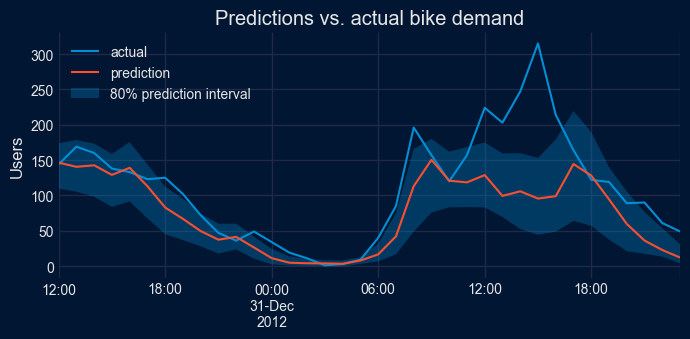

In [16]:
# Plot predictions vs. actual values for the held-out test period
# ==============================================================================
set_dark_theme()
preds = results_eval.predictions
fig, ax = plt.subplots(figsize=(7, 3.5))
data.set_index('date_time').loc[preds.index, 'users'].plot(ax=ax, label='actual')
preds['pred'].plot(ax=ax, label='prediction')
if {'lower_bound', 'upper_bound'}.issubset(preds.columns):
    ax.fill_between(
        preds.index, preds['lower_bound'], preds['upper_bound'],
        alpha=0.3, label='80% prediction interval'
    )
ax.set_title('Predictions vs. actual bike demand')
ax.set_ylabel('Users')
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
# Ask the assistant to interpret the forecast results
# ==============================================================================
answer = assistant.ask(
    prompt          = "Explain the results of this forecast, including the metrics and predictions.",
    result = results_eval
)
answer.show_explanation()

/var/folders/wt/8tvn563d5v55nspfbydgqb9r0000gp/T/ipykernel_47478/2778621502.py:3: DataSentToLLMWarning: `send_data_to_llm=False` does not apply to `result`: the predicted values it carries are sent to the LLM, because a question about a result cannot be answered from summary statistics alone. Your input data is not sent: a result holds only the model's output, never the data it was fitted on. To keep predictions local, ask without `result`.
  answer = assistant.ask(


╭────────────────────────────────── Assistant Response ──────────────────────────────────╮
│                                                                                        │
│  The recursive forecasting model successfully predicted hourly user demand over a      │
│  36-step horizon using a LightGBM regressor. The model achieved a Mean Absolute Error  │
│  of 37.133737 and a Mean Absolute Scaled Error of 0.576707, indicating that the model  │
│  performs better than the naive baseline. The point predictions are accompanied by an  │
│  80 percent prediction interval generated via bootstrapping.                           │
│                                                                                        │
│  Model Configuration                                                                   │
│                                                                                        │
│   • Forecaster: ForecasterRecursive with an LGBMRegressor.                             │
│   • Lag features: 1, 2, 3, 4, 5, 6, 24, 25, 168, and 169.                              │
│   • Window features: Rolling mean and standard deviation over 6-hour and 24-hour       │
│     windows, and a rolling mean over a 168-hour window.                                │
│   • Exogenous variables: holiday, weather (automatically processed as a categorical    │
│     feature), and temp, as well as extracted calendar features (hour, day of week,     │
│     weekend, and month).                                                               │
│                                                                                        │
│  Evaluation Metrics                                                                    │
│                                                                                        │
│   • Mean Absolute Error (MAE): 37.133737                                               │
│   • Mean Squared Error (MSE): 3493.960695                                              │
│   • Mean Absolute Scaled Error (MASE): 0.576707                                        │
│   • Mean Absolute Percentage Error (MAPE): 0.406163                                    │
│                                                                                        │
│  The model performance is strong, as demonstrated by the MASE of 0.576707. Since this  │
│  value is below 1, the model represents a substantial improvement over the naive       │
│  baseline.                                                                             │
│                                                                                        │
│  Predictions Summary                                                                   │
│                                                                                        │
│  Since some intermediate rows are omitted, the overall characteristics of the 36-step  │
│  forecast are described by the summary statistics:                                     │
│                                                                                        │
│   • Point Predictions (pred): The forecasted hourly users have a mean of               │
│     76.04888776543231, with values ranging from a minimum of 3.279099775408038 to a    │
│     maximum of 150.37388052594986.                                                     │
│   • Lower Prediction Bound: The 80 percent confidence lower bound has a mean of        │
│     43.08047185401101, with a minimum of -0.6946243906513812 and a maximum of          │
│     109.55279358543561.                                                                │
│   • Upper Prediction Bound: The 80 percent confidence upper bound has a mean of        │
│     109.67120744085483, with a minimum of 8.00746344864623 and a maximum of            │
│     219.1398135120457.                                                                 │
│                                                                                      

### Prediction mode

In prediction mode, the model trains on the entire dataset and forecasts the next `steps` time points. Because the data includes exogenous variables (`holiday`, `weather`, `temp`), their future values must be supplied via the `exog` argument.

In [18]:
# Forecast the next 36 hours using the entire dataset (prediction mode)
# ==============================================================================
# Simulate future values of exogenous variables for the next 36 hours
exog = data[['holiday', 'weather', 'temp']].tail(36).copy()
exog.index = pd.date_range(
    start=pd.to_datetime(data['date_time'].max()) + pd.Timedelta(hours=1),
    periods=36,
    freq='h'
)

results_pred = assistant.forecast(
    data        = data,
    target      = 'users',
    date_column = 'date_time',
    steps       = 36,
    interval    = [0.1, 0.9],
    test_size   = None,        # Use the entire dataset (prediction mode)
    exog        = exog,        # Future values of exogenous variables
    profile     = profile,
    plan        = plan_refined
)

display(results_pred.predictions.head())

╭─────────────────────────────── IgnoredArgumentWarning ───────────────────────────────╮
│ A pre-built `plan` was provided, so the following argument(s) are ignored:           │
│ ['interval']. To change these, refine the plan with `refine_plan()` before calling.  │
│                                                                                      │
│ Category : skforecast.exceptions.IgnoredArgumentWarning                              │
│ Location :                                                                           │
│ /opt/homebrew/Caskroom/miniconda/base/envs/skforecast_ai_py13/lib/python3.13/site-pa │
│ ckages/skforecast_ai/_utils.py:402                                                   │
│ Suppress : warnings.simplefilter('ignore', category=IgnoredArgumentWarning)          │
╰──────────────────────────────────────────────────────────────────────────────────────╯

,pred,lower_bound,upper_bound
2013-01-01 00:00:00,23.584995,14.869269,31.945206
2013-01-01 01:00:00,13.163759,4.640405,22.051885
2013-01-01 02:00:00,7.925382,3.187434,14.646704
2013-01-01 03:00:00,5.533322,1.919760,9.619885
2013-01-01 04:00:00,6.232066,1.744164,10.758656


In [19]:
# Full results object
# ==============================================================================
results_pred

                          Dataset Profile                          
┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property       ┃ Value                                          ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Format         │ single                                         │
├────────────────┼────────────────────────────────────────────────┤
│ Series         │ 1                                              │
├────────────────┼────────────────────────────────────────────────┤
│ Observations   │ 17544                                          │
├────────────────┼────────────────────────────────────────────────┤
│ Frequency      │ h                                              │
├────────────────┼────────────────────────────────────────────────┤
│ Target         │ users                                          │
├────────────────┼────────────────────────────────────────────────┤
│ Exog columns   │ holiday, weather, temp  (categorical: weather) │
├────────────────┼────────────────────────────────────────────────┤
│ Missing values │ None                                           │
└────────────────┴────────────────────────────────────────────────┘

                                    Recommendation                                     
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property              ┃ Value                                                       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Task type             │ single_series                                               │
├───────────────────────┼─────────────────────────────────────────────────────────────┤
│ Forecaster            │ ForecasterRecursive                                         │
├───────────────────────┼─────────────────────────────────────────────────────────────┤
│ Forecaster candidates │ ForecasterRecursive, ForecasterDirect, ForecasterFoundation │
├───────────────────────┼─────────────────────────────────────────────────────────────┤
│ Estimator             │ LGBMRegressor                                               │
├───────────────────────┼─────────────────────────────────────────────────────────────┤
│ Estimator candidates  │ LGBMRegressor, XGBRegressor, Ridge                          │
└───────────────────────┴─────────────────────────────────────────────────────────────┘

╭───────────────────────────────── Profile Explanation ──────────────────────────────────╮
│                                                                                        │
│  A single-series ML forecaster (ForecasterRecursive) is recommended. Data: 17544       │
│  observations, 'h' frequency. Alternative forecasters: ['ForecasterDirect',            │
│  'ForecasterFoundation']. Estimator: LGBMRegressor. A gradient boosting model is       │
│  preferred for a dataset of this size (17544 observations). Alternative estimators:    │
│  ['XGBRegressor', 'Ridge']. 3 exogenous variables (1 categorical) available as         │
│  predictors.                                                                           │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯
                                      Forecast Plan                                       
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property          ┃ Value                                                              ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Task type         │ single_series                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Forecaster        │ ForecasterRecursive                                             

### Code-only mode

Use `forecast_code()` when you want to preview or export the reproducible script without executing it. This is useful for code review, auditing the generated pipeline, or running the script in a separate environment.

In [20]:
# Generate the reproducible script without executing it
# ==============================================================================
code_result = assistant.forecast_code(
    data        = data,
    target      = 'users',
    date_column = 'date_time',
    steps       = 36,
    test_size   = 36,
    profile     = profile,
    plan        = plan_refined
)
code_result.show_code()

### The ForecastResult object

Both `forecast()` modes return a `ForecastResult`, a lightweight container that bundles everything the assistant used and produced.

| Attribute | Type | Description |
|---|---|---|
| `predictions` | DataFrame | Forecasted values. When intervals are requested, the bound columns are included alongside the point predictions. |
| `metrics` | DataFrame or None | Evaluation metrics (`MAE`, `MSE`, `MASE`), one row per series. `None` in prediction mode. |
| `code` | str | The exact standalone **skforecast** script that produced the forecast, ready to run on its own. |
| `profile` | `ForecastingProfile` | The data profile behind the forecast. |
| `plan` | `ForecastPlan` | The detailed configuration that was executed. |

## Backtesting

The backtesting branch uses the same `profile` and `plan` as the forecast branch but evaluates the model's historical performance through time series cross-validation. The key decision is how to configure the `TimeSeriesFold` object, which controls exactly how the historical data is partitioned into successive training and test windows.

skforecast-ai provides three distinct ways to define this validation strategy:

1. **Explicit instantiation (recommended)**: manually construct a `TimeSeriesFold` and pass it directly to `backtest()`. Use this when you already know your exact operational constraints.

2. **Deterministic `create_cv()`**: allow the assistant to derive a sensible `TimeSeriesFold` from the profile and plan using rule-based defaults. You can override individual parameters explicitly.

3. **LLM `create_cv()` (with a prompt)**: describe your deployment use case in natural language. The LLM translates your description into a fully-configured `TimeSeriesFold`, accompanied by an explanation you can audit.

### Define the backtesting strategy

#### Manual TimeSeriesFold

In [21]:
# Create your own TimeSeriesFold object
# ==============================================================================
end_train = '2012-08-31 23:59:00'
cv = TimeSeriesFold(
    steps              = 36,
    initial_train_size = end_train,
    refit              = False,
    verbose            = False
)
cv

TimeSeriesFold(
    initial_train_size    = 2012-08-31 23:59:00,
    steps                 = 36,
    fold_stride           = 36,
    window_size           = None,
    differentiation       = None,
    refit                 = False,
    fixed_train_size      = True,
    gap                   = 0,
    skip_folds            = None,
    allow_incomplete_fold = True,
    return_all_indexes    = False,
    verbose               = False,
)

#### Deterministic create_cv()

In [22]:
# Let the assistant derive a TimeSeriesFold with rule-based defaults
# ==============================================================================
cv_det, cv_det_explanation = assistant.create_cv(
    profile            = profile,
    plan               = plan_refined,
    initial_train_size = end_train,
    refit              = False,
)

print(cv_det_explanation)
cv_det

Initial training up to 2012-08-31 23:59:00, expanding window, no refit, 36-step horizon, 82 folds.


TimeSeriesFold(
    initial_train_size    = 2012-08-31 23:59:00,
    steps                 = 36,
    fold_stride           = 36,
    window_size           = None,
    differentiation       = None,
    refit                 = False,
    fixed_train_size      = False,
    gap                   = 0,
    skip_folds            = None,
    allow_incomplete_fold = True,
    return_all_indexes    = False,
    verbose               = False,
)

#### LLM create_cv() with a natural-language

Rather than manually configuring `TimeSeriesFold` parameters, you can describe your backtesting strategy in natural language and let the assistant translate it into a rigorous cross-validation schema.

In [23]:
# Let the assistant create the TimeSeriesFold from a natural-language prompt
# ==============================================================================
prompt = (
    "I forecast bike demand 36 hours ahead. "
    "The model should be trained once on all data up to the end of August 2012, 23:59. "
    "Do not refit the model as the window rolls forward."
)
cv_llm, cv_llm_explanation = assistant.create_cv(
    profile = profile,
    plan    = plan_refined,
    prompt  = prompt
)

In [24]:
# TimeSeriesFold derived from the prompt
# ==============================================================================
cv_llm

TimeSeriesFold(
    initial_train_size    = 2012-08-31 23:59:00,
    steps                 = 36,
    fold_stride           = 36,
    window_size           = None,
    differentiation       = None,
    refit                 = False,
    fixed_train_size      = False,
    gap                   = 0,
    skip_folds            = None,
    allow_incomplete_fold = True,
    return_all_indexes    = False,
    verbose               = False,
)

In [25]:
# LLM reasoning behind the TimeSeriesFold configuration
# ==============================================================================
print(textwrap.fill(cv_llm_explanation, width=88))

The model is trained exactly once up to the end of August 2012 ('2012-08-31 23:59:00')
and is not refitted during backtesting (refit=False). This mimics a deployment scenario
where a model is trained statically and evaluated on subsequent rolling windows without
retraining, simulating performance degradation over time. Initial training up to
2012-08-31 23:59:00, expanding window, no refit, 36-step horizon, 82 folds.


Since the `prompt` correctly describes the intended use case, the `cv_llm` object returned by `create_cv()` matches the one we built manually. However, it was derived entirely from a natural-language description. The assistant also returns a `cv_llm_explanation` string that details the choices it made, allowing you to verify that the resulting `TimeSeriesFold` matches your intended strategy before executing the backtest.

### Run the backtest

In [26]:
# Run backtesting, reusing the pre-computed profile and plan
# ==============================================================================
results_backtest = assistant.backtest(
    data        = data,
    target      = 'users',
    date_column = 'date_time',
    cv          = cv,           # TimeSeriesFold object
    interval    = [0.1, 0.9],   # 80% prediction interval
    profile     = profile,      # Reuse the pre-computed profile
    plan        = plan_refined  # Reuse the refined plan
)

results_backtest.show_explanation()
display(results_backtest.metrics)
display(results_backtest.predictions.head())

╭─────────────────────────────── IgnoredArgumentWarning ───────────────────────────────╮
│ A pre-built `plan` was provided, so the following argument(s) are ignored:           │
│ ['interval']. To change these, refine the plan with `refine_plan()` before calling.  │
│                                                                                      │
│ Category : skforecast.exceptions.IgnoredArgumentWarning                              │
│ Location :                                                                           │
│ /opt/homebrew/Caskroom/miniconda/base/envs/skforecast_ai_py13/lib/python3.13/site-pa │
│ ckages/skforecast_ai/_utils.py:402                                                   │
│ Suppress : warnings.simplefilter('ignore', category=IgnoredArgumentWarning)          │
╰──────────────────────────────────────────────────────────────────────────────────────╯

  0%|          | 0/82 [00:00<?, ?it/s]

╭───────────────────────────────── Backtest Explanation ─────────────────────────────────╮
│                                                                                        │
│  Initial training up to 2012-08-31 23:59:00, fixed window, no refit, 36-step horizon,  │
│  82 folds. Results — mean_absolute_error: 50.6124, mean_squared_error: 6749.5347,      │
│  mean_absolute_scaled_error: 0.8255, mean_absolute_percentage_error: 0.5470.           │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯

,mean_absolute_error,mean_squared_error,mean_absolute_scaled_error,mean_absolute_percentage_error
0,50.612411,6749.534659,0.825461,0.547002


,fold,pred,lower_bound,upper_bound
2012-09-01 00:00:00,0,131.068427,102.190679,157.825889
2012-09-01 01:00:00,0,103.290951,70.073384,133.698959
2012-09-01 02:00:00,0,71.023043,42.422390,95.704164
2012-09-01 03:00:00,0,43.702485,21.985747,67.910837
2012-09-01 04:00:00,0,19.027268,5.202298,31.766795


In [27]:
# Plot prediction intervals vs real value
# ==============================================================================
predictions = results_backtest.predictions
data_test = data.set_index("date_time").loc[predictions.index, :]

fig = go.Figure([
    go.Scatter(name='Prediction', x=predictions.index, y=predictions['pred'], mode='lines'),
    go.Scatter(
        name='Real value', x=data_test.index, y=data_test['users'], mode='lines',
    ),
    go.Scatter(
        name='Upper Bound', x=predictions.index, y=predictions['upper_bound'], mode='lines',
        marker=dict(color="#444"), line=dict(width=0), showlegend=False
    ),
    go.Scatter(
        name='Lower Bound', x=predictions.index, y=predictions['lower_bound'], marker=dict(color="#444"),
        line=dict(width=0), mode='lines', fillcolor='rgba(68, 68, 68, 0.3)', fill='tonexty', showlegend=False
    )
])
fig.update_layout(
    title="Real value vs predicted in test data",
    xaxis_title="Date time",
    yaxis_title="users",
    width=800,
    height=400,
    margin=dict(l=20, r=20, t=35, b=20),
    hovermode="x",
    legend=dict(orientation="h", yanchor="top", y=1.1, xanchor="left", x=0.001),
    # Initial zoom on x axis betwee 1 oct to 10 oct
    xaxis=dict(range=['2012-10-01', '2012-10-10'])
)
fig.show()

In [28]:
# Ask the assistant to interpret the backtesting results
# ==============================================================================
answer = assistant.ask(
    prompt = (
        "Explain the results of this backtesting, including the strategy, metrics, "
        "and predictions. Is the model good enough to deploy?"
    ),
    result = results_backtest
)
answer.show_explanation()

/var/folders/wt/8tvn563d5v55nspfbydgqb9r0000gp/T/ipykernel_47478/2686622943.py:3: DataSentToLLMWarning: `send_data_to_llm=False` does not apply to `result`: the predicted values it carries are sent to the LLM, because a question about a result cannot be answered from summary statistics alone. Your input data is not sent: a result holds only the model's output, never the data it was fitted on. To keep predictions local, ask without `result`.
  answer = assistant.ask(


╭────────────────────────────────── Assistant Response ──────────────────────────────────╮
│                                                                                        │
│  The backtesting evaluation shows that the recursive machine learning model            │
│  outperforms a naive baseline, as indicated by a Mean Absolute Scaled Error of         │
│  0.825461. Based on this validation, the model is a strong candidate for deployment    │
│  because it beats the naive benchmark, though the final decision depends on whether    │
│  the Mean Absolute Error of 50.612411 is acceptable for your specific business         │
│  requirements.                                                                         │
│                                                                                        │
│  Backtesting Strategy                                                                  │
│                                                                                        │
│  The evaluation was conducted using a fixed-window cross-validation strategy with the  │
│  following configuration:                                                              │
│                                                                                        │
│   • Initial training size: up to 2012-08-31 23:59:00                                   │
│   • Refit: False (the model was trained once and not retrained between folds)          │
│   • Fixed training size: True                                                          │
│   • Forecast horizon (steps): 36                                                       │
│   • Fold stride: 36                                                                    │
│   • Number of folds: 82                                                                │
│                                                                                        │
│  Evaluation Metrics                                                                    │
│                                                                                        │
│  The model performance across the 82 folds is summarized by these metrics:             │
│                                                                                        │
│   • Mean Absolute Error (MAE): 50.612411                                               │
│   • Mean Squared Error (MSE): 6749.534659                                              │
│   • Mean Absolute Scaled Error (MASE): 0.825461                                        │
│   • Mean Absolute Percentage Error (MAPE): 0.547002                                    │
│                                                                                        │
│  The Mean Absolute Scaled Error (MASE) of 0.825461 is below 1, which means the model   │
│  successfully beats the naive baseline forecast.                                       │
│                                                                                        │
│  Prediction Summary                                                                    │
│                                                                                        │
│  Across all 2928 generated prediction rows, the forecasted values and their 80%        │
│  bootstrapping prediction intervals are summarized below:                              │
│                                                                                        │
│   • Predictions (pred): minimum of -0.023663164693859554, maximum of                   │
│     857.9492020031881, and a mean of 229.01394244959437.                               │
│   • Lower bound: minimum of -3.896262646241344, maximum of 786.4757854246864, and a    │
│     mean of 179.59625708651254.                                                        │
│   • Upper bound: minimum of 4.550956713038428, maximum of 886.3325069970466, and a     │
│     mean of 275.6659499918083.                                                       

### Code-only mode

Use `backtest_code()` to generate the reproducible backtesting script without executing it.

In [29]:
# Generate the reproducible backtest script without executing it
# ==============================================================================
code_bt = assistant.backtest_code(
    data        = data,
    target      = 'users',
    date_column = 'date_time',
    cv          = cv,
    profile     = profile,
    plan        = plan_refined
)
code_bt.show_code()

### The BacktestResult object

The `backtest()` method returns a `BacktestResult`, a lightweight container that bundles all the backtesting artifacts.

| Attribute | Type | Description |
|---|---|---|
| `predictions` | DataFrame | Full out-of-sample backtest predictions across all folds. |
| `metrics` | DataFrame | Backtesting metrics (`MAE`, `MSE`, `MASE`), one row per series. |
| `cv_config` | dict | Resolved `TimeSeriesFold` parameters for full traceability of the validation strategy. |
| `code` | str | The exact standalone **skforecast** script that reproduces the backtesting workflow. |
| `explanation` | str | Human-readable summary of the backtesting configuration and results. |
| `profile` | `ForecastingProfile` | The data profile behind the backtest. |
| `plan` | `ForecastPlan` | The detailed configuration that was executed. |

In [30]:
# Full results object
# ==============================================================================
results_backtest

╭───────────────────────────────── Backtest Explanation ─────────────────────────────────╮
│                                                                                        │
│  Initial training up to 2012-08-31 23:59:00, fixed window, no refit, 36-step horizon,  │
│  82 folds. Results — mean_absolute_error: 50.6124, mean_squared_error: 6749.5347,      │
│  mean_absolute_scaled_error: 0.8255, mean_absolute_percentage_error: 0.5470.           │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯
       Cross-Validation Configuration       
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Parameter          ┃               Value ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ steps              │                  36 │
├────────────────────┼─────────────────────┤
│ initial_train_size │ 2012-08-31 23:59:00 │
├────────────────────┼─────────────────────┤
│ refit              │               False │
├────────────────────┼─────────────────────┤
│ fixed_train_size   │                True │
├────────────────────┼─────────────────────┤
│ gap                │                   0 │
├────────────────────┼─────────────────────┤
│ fold_stride        │                  36 │
├────────────────────┼─────────────────────┤
│ differentiation    │                None │
├────────────────────┼─────────────────────┤
│ n_folds            │                  82 │
└────────────────────┴─────────────────────┘
                                     Backtest Metrics                                     
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ mean_absolute_error ┃ mean_squared_error ┃ mean_absolute_scale… ┃ mean_absolute_perce… ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│             50.6124 │          6749.5347 │               0.8255 │               0.5470 │
└─────────────────────┴────────────────────┴──────────────────────┴──────────────────────┘
                    Backtest Predictions (2928 rows)                    
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Index               ┃    fold ┃     pred ┃ lower_bound ┃ upper_bound ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ 2012-09-01 00:00:00 │  0.0000 │ 131.0684 │    102.1907 │    157.8259 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-09-01 01:00:00 │  0.0000 │ 103.2910 │     70.0734 │    133.6990 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-09-01 02:00:00 │  0.0000 │  71.0230 │     42.4224 │     95.7042 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-09-01 03:00:00 │  0.0000 │  43.7025 │     21.9857 │     67.9108 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-09-01 04:00:00 │  0.0000 │  19.0273 │      5.2023 │     31.7668 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ ...                 │     ... │      ... │         ... │         ... │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-12-31 19:00:00 │ 81.0000 │  99.4355 │     45.6889 │    129.4981 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-12-31 20:00:00 │ 81.0000 │  74.2794 │     27.6347 │     93.9092 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-12-31 21:00:00 │ 81.0000 │  49.4804 │     19.1027 │     68.6619 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-12-31 22:00:00 │ 81.0000 │  29.2177 │     11.3309 │     45.8307 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-12-31 23:00:00 │ 81.0000 │  15.9060 │      6.3630 │     28.9789 │
└─────────────────────┴─────────┴──────────┴─────────────┴─────────────┘
                   

## Comparing forecaster configurations

Choosing a forecasting model should not rely on intuition alone. Two configurations that look equally reasonable can perform very differently once evaluated on real temporal data. The most reliable approach is to test every candidate under **identical conditions** and compare their metrics.

The `compare()` method does exactly that. It receives a list of candidate configurations, backtests each one using the same `TimeSeriesFold` strategy, and returns a leaderboard ranked by the selected metric.

In the step-by-step path, the key argument is `profile`. Passing the profile computed at the beginning of this tutorial skips profiling entirely and guarantees that every candidate is evaluated against the **same** data profile. Note that `compare()` does not accept a `plan`: each candidate derives its own plan from the shared profile, which is precisely what makes the candidates differ.

Candidates can be provided in two ways:

+ **Automatic candidates (`candidates=None`)**: the assistant builds the comparison set from `profile.forecaster_candidates`, using the forecaster types identified as suitable during profiling. This is useful when exploring a new dataset without a predefined shortlist.

+ **Explicit candidates (recommended)**: pass a list of `(name, config)` tuples, where `name` labels the row in the leaderboard and `config` holds the same override keys understood by `plan()`: `'forecaster'`, `'estimator'`, `'estimator_kwargs'`, `'lags'` and `'window_features'`. This provides full control and makes the resulting table easier to interpret.

A failed candidate does not stop the comparison. Instead, a `CandidateFailedWarning` is issued, the row records the error and is placed last.

<div role="note"
    style="background: rgba(0,191,191,.08); border-left: 6px solid #00bfa5;
        border-radius: 6px; padding: 10px 12px; margin: 1em 0;">

<p style="display:flex; align-items:center; font-size:1rem; color:#00bfa5;
        margin:0 0 6px 0; font-weight:600;">
<span style="margin-right:6px; font-size:18px;">💡</span>
<strong style="margin-right:6px; font-size:18px;">Tip</strong>
</p>

<p>

All candidates use the same cross-validation strategy, ensuring a fair comparison. However, the results are only meaningful if the <code>cv</code> setup reflects the real use case where the model will be deployed. For example, if the production system retrains weekly, the backtest should also refit weekly. If the model is expected to forecast 24 hours ahead, the backtest should use a 24-hour horizon.

The evaluation window must also be representative. A period that is too short or dominated by unusual events (holidays, outages, or exceptional peaks) may favor a candidate that performs poorly over time. Define the validation setup carefully before comparing models so the final ranking is reliable.

</p>

</div>

### Automatic candidates

In [ ]:
# Compare the forecaster candidates suggested by the profile
# ==============================================================================
results_compare = assistant.compare(
    data        = data,
    target      = 'users',
    date_column = 'date_time',
    cv          = cv,       # Same TimeSeriesFold used in the backtest above
    candidates  = None,     # Candidates suggested by the assistant 
    profile     = profile   # Reuse the pre-computed profile
)

Comparing forecasters:   0%|          | 0/3 [00:00<?, ?it/s]

In [32]:
# Ranked leaderboard
# ==============================================================================
results_compare.results

,rank,name,forecaster,estimator,mean_absolute_error,mean_squared_error,mean_absolute_scaled_error,mean_absolute_percentage_error
0,1,ForecasterFoundation,ForecasterFoundation,Chronos-2,38.436160,4231.326474,0.597467,0.611349
1,2,ForecasterRecursive,ForecasterRecursive,LGBMRegressor,46.312218,5495.881638,0.749598,0.472735
2,3,ForecasterDirect,ForecasterDirect,LGBMRegressor,49.298312,5936.622526,0.797930,0.499413


In [33]:
# Deterministic summary of the comparison
# ==============================================================================
results_compare.show_explanation()

╭──────────────────────────────── Comparison Explanation ────────────────────────────────╮
│                                                                                        │
│  Compared 3 configurations, ranked ascending by mean_absolute_error. Shared            │
│  cross-validation strategy: Initial training up to 2012-08-31 23:59:00, fixed window,  │
│  no refit, 36-step horizon, 82 folds. Best: 'ForecasterFoundation'                     │
│  (ForecasterFoundation / Chronos-2) = 38.4362, 17.0% ahead of 'ForecasterRecursive'    │
│  (46.3122).                                                                            │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯

### Explicit candidates

In practice, you will often already have a shortlist in mind: a fast baseline, a gradient boosting model, or a variant with a richer feature set. Passing explicit `(name, config)` tuples keeps the comparison focused and makes the resulting leaderboard easy to understand at a glance.

The `config` dictionary accepts the same overrides as `plan()`. Any omitted option falls back to the deterministic recommendation derived from the shared profile, so candidates can remain concise. For example, `{'forecaster': 'ForecasterDirect'}` changes only the forecaster while keeping the recommended estimator, lags, and features.

<div role="alert" style="background: rgba(255,145,0,.08); border-left: 6px solid #ff9100; border-radius: 6px; padding: 10px 12px; margin: 1em 0;">

<p style="display:flex; align-items:center; font-size:1rem; color:#ff9100; margin:0 0 6px 0; font-weight:600;">
    <span style="margin-right:6px; font-size:18px;">⚠️</span>
    <strong style="margin-right:6px; font-size:18px;">Computational cost</strong>
</p>

<p>
Each candidate is backtested independently across all folds, so runtime increases with both the number and complexity of the configurations. Comparing four candidates will take roughly four times as long as running one backtest.

Start with a small set of clearly different options, review the results, and refine from there. Testing many near-identical variants is costly and rarely useful.
</p>

</div>

In [ ]:
# Compare an explicit shortlist of configurations
# ==============================================================================
candidates = [
    (
        "ridge_baseline",
        {
            "forecaster": "ForecasterRecursive",
            "estimator" : "Ridge",
            "lags"      : 24,
        }
    ),
    (
        "lgbm_daily_lags",
        {
            "forecaster": "ForecasterRecursive",
            "estimator" : "LGBMRegressor",
            "lags"      : 24,
        }
    ),
    (
        "refined_plan",
        {
            "forecaster"      : plan_refined.forecaster,
            "estimator"       : plan_refined.estimator,
            "lags"            : plan_refined.forecaster_kwargs.get("lags"),
            "window_features" : plan_refined.forecaster_kwargs.get("window_features"),
        }
    ),
    (
        "lgbm_direct",
        {
            "forecaster": "ForecasterDirect",
            "estimator" : "LGBMRegressor",
            "lags"      : 24,
        }
    ),
    (
        "foundation_model",
        {
            "forecaster": "ForecasterFoundation"
        }
    ),
]

results_compare = assistant.compare(
    data        = data,
    target      = 'users',
    date_column = 'date_time',
    cv          = cv,
    candidates  = candidates,  # Specific candidates to compare
    metric      = ['mean_absolute_error', 'mean_absolute_scaled_error'],
    profile     = profile
)

Comparing forecasters:   0%|          | 0/5 [00:00<?, ?it/s]

The `refined_plan` candidate reuses the forecaster, estimator, lags and window features of the plan produced by `refine_plan()`. This is the recommended way to validate a refined plan: the leaderboard shows whether the extra domain knowledge actually improves the metrics compared to the deterministic baselines.

When several metrics are requested, all of them are shown as columns but only the **first** one drives the ranking.

In [35]:
# Ranked leaderboard, sorted by the first metric requested
# ==============================================================================
results_compare.results

,rank,name,forecaster,estimator,mean_absolute_error,mean_absolute_scaled_error
0,1,foundation_model,ForecasterFoundation,Chronos-2,38.436160,0.597467
1,2,lgbm_direct,ForecasterDirect,LGBMRegressor,50.224908,0.819189
2,3,refined_plan,ForecasterRecursive,LGBMRegressor,50.612411,0.825461
3,4,lgbm_daily_lags,ForecasterRecursive,LGBMRegressor,55.517689,0.905517
4,5,ridge_baseline,ForecasterRecursive,Ridge,93.145620,1.519244


### Inspect individual candidates

Because every candidate is a full `BacktestResult`, the details of any individual configuration remain available, including its metrics, its predictions and the standalone script that generated them.

In [36]:
# Inspect a specific candidate
# ==============================================================================
candidate = results_compare.candidates['foundation_model']

display(candidate.metrics)
display(candidate.predictions.head())
candidate.show_code()

,mean_absolute_error,mean_absolute_scaled_error
0,38.43616,0.597467


,level,fold,pred
2012-09-01 00:00:00,users,0,148.059464
2012-09-01 01:00:00,users,0,102.715004
2012-09-01 02:00:00,users,0,66.084427
2012-09-01 03:00:00,users,0,40.878662
2012-09-01 04:00:00,users,0,29.577866


### Reuse the winning configuration

The most useful result of a comparison is often not the leaderboard, but `best_candidate`. It is a complete `BacktestResult` carrying both the winning `profile` and `plan`, so it can be fed back into the step-by-step workflow without manually rebuilding the configuration.

In [37]:
# Winning configuration
# ==============================================================================
print(f"Best candidate: {results_compare.best_name}")
results_compare.best_candidate.plan

Best candidate: foundation_model


              Forecast Plan              
┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property       ┃ Value                ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│ Task type      │ foundation           │
├────────────────┼──────────────────────┤
│ Forecaster     │ ForecasterFoundation │
├────────────────┼──────────────────────┤
│ Estimator      │ Chronos-2            │
├────────────────┼──────────────────────┤
│ Steps          │ 36                   │
├────────────────┼──────────────────────┤
│ Frequency      │ h                    │
├────────────────┼──────────────────────┤
│ Use exog       │ True                 │
├────────────────┼──────────────────────┤
│ Interval       │ None                 │
├────────────────┼──────────────────────┤
│ Primary metric │ mean_absolute_error  │
├────────────────┼──────────────────────┤
│ Preprocessing  │ 1 step               │
└────────────────┴──────────────────────┘

                                   Preprocessing Steps                                    
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Step                    ┃ Reason                                                       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ handle_categorical_exog │ Categorical exogenous variables detected: ['weather'].       │
│                         │ Chronos-2 consumes categorical covariates natively, so no    │
│                         │ encoding is needed.                                          │
└─────────────────────────┴──────────────────────────────────────────────────────────────┘

╭─────────────────────────────────── Plan Explanation ───────────────────────────────────╮
│                                                                                        │
│  Plan: ForecasterFoundation + Chronos-2. No lag or window features: the foundation     │
│  model forecasts directly from the raw context window. Exogenous variables included.   │
│  MAE is interpretable, robust to outliers, and works at any scale.                     │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯

In [38]:
# Produce the final forecast with the winning configuration
# ==============================================================================
results_pred_best = assistant.forecast(
    data        = data,
    target      = 'users',
    date_column = 'date_time',
    steps       = 36,
    interval    = [0.1, 0.9],
    test_size   = None,                                # Prediction mode
    exog        = exog,                                # Future values of exogenous variables
    profile     = results_compare.profile,             # Shared profile
    plan        = results_compare.best_candidate.plan  # Winning plan
)

results_pred_best.show_code()

╭─────────────────────────────── IgnoredArgumentWarning ───────────────────────────────╮
│ A pre-built `plan` was provided, so the following argument(s) are ignored:           │
│ ['interval']. To change these, refine the plan with `refine_plan()` before calling.  │
│                                                                                      │
│ Category : skforecast.exceptions.IgnoredArgumentWarning                              │
│ Location :                                                                           │
│ /opt/homebrew/Caskroom/miniconda/base/envs/skforecast_ai_py13/lib/python3.13/site-pa │
│ ckages/skforecast_ai/_utils.py:402                                                   │
│ Suppress : warnings.simplefilter('ignore', category=IgnoredArgumentWarning)          │
╰──────────────────────────────────────────────────────────────────────────────────────╯

### Explain mode (comparison)

Like any other result, a `ComparisonResult` can be passed to `ask()` to explain why the ranking looks the way it does. However, the LLM cannot change the outcome: all metrics and rankings are computed deterministically before it sees the result.

In [39]:
# Ask the assistant to interpret the comparison
# ==============================================================================
answer = assistant.ask(
    prompt = (
        "Explain the comparison results. Is the margin between the top candidates "
        "meaningful, or are they practically equivalent?"
    ),
    result = results_compare
)
answer.show_explanation()

/var/folders/wt/8tvn563d5v55nspfbydgqb9r0000gp/T/ipykernel_47478/2283091584.py:3: DataSentToLLMWarning: `send_data_to_llm=False` does not apply to `result`: the predicted values it carries are sent to the LLM, because a question about a result cannot be answered from summary statistics alone. Your input data is not sent: a result holds only the model's output, never the data it was fitted on. To keep predictions local, ask without `result`.
  answer = assistant.ask(


╭────────────────────────────────── Assistant Response ──────────────────────────────────╮
│                                                                                        │
│  The foundation model configuration, using Chronos-2, outperformed all other           │
│  candidates with a mean absolute error of 38.436160. The margin between the top two    │
│  candidates is meaningful, as the foundation model is 23.5% ahead of the               │
│  second-placed LGBM direct model. Both models, along with two other gradient boosting  │
│  configurations, achieved mean absolute scaled error values below 1, meaning they      │
│  successfully outperformed the naive baseline.                                         │
│                                                                                        │
│  Performance of Evaluated Candidates                                                   │
│                                                                                        │
│  The 5 candidates were evaluated using a shared cross-validation strategy consisting   │
│  of 82 folds and a 36-step forecast horizon. They are ranked in ascending order by     │
│  their mean absolute error:                                                            │
│                                                                                        │
│   • foundation_model (ForecasterFoundation using Chronos-2): mean absolute error of    │
│     38.436160, mean absolute scaled error of 0.597467.                                 │
│   • lgbm_direct (ForecasterDirect using LGBMRegressor): mean absolute error of         │
│     50.224908, mean absolute scaled error of 0.819189.                                 │
│   • refined_plan (ForecasterRecursive using LGBMRegressor): mean absolute error of     │
│     50.612411, mean absolute scaled error of 0.825461.                                 │
│   • lgbm_daily_lags (ForecasterRecursive using LGBMRegressor): mean absolute error of  │
│     55.517689, mean absolute scaled error of 0.905517.                                 │
│   • ridge_baseline (ForecasterRecursive using Ridge): mean absolute error of           │
│     93.145620, mean absolute scaled error of 1.519244.                                 │
│                                                                                        │
│  Interpretation of the Winning Margin                                                  │
│                                                                                        │
│  The margin between the top two candidates is notable. The foundation_model, with a    │
│  mean absolute error of 38.436160, is 23.5% ahead of the second-placed lgbm_direct     │
│  candidate, which scored 50.224908. This suggests a clear advantage for the            │
│  foundation model on this dataset.                                                     │
│                                                                                        │
│  In contrast, the margin between the second-place lgbm_direct and third-place          │
│  refined_plan candidates is much smaller, with their mean absolute errors separated    │
│  only by 50.224908 and 50.612411.                                                      │
│                                                                                        │
│  Naive Baseline Comparison                                                             │
│                                                                                        │
│  A mean absolute scaled error (MASE) below 1 indicates that a candidate beats the      │
│  naive baseline, whereas a value above 1 does not.                                     │
│                                                                                        │
│   • The top four candidates (foundation_model, lgbm_direct, refined_plan, and          │
│     lgbm_daily_lags) all achieved MASE values below 1, indicating they successfully  

### The ComparisonResult object

The `compare()` method returns a `ComparisonResult`, which groups the shared setup, the ranked leaderboard, and the individual backtests in a single object.

| Attribute | Type | Description |
|---|---|---|
| `results` | DataFrame | Ranked leaderboard, one row per candidate, sorted best to worst. Columns: `rank`, `name`, `forecaster`, `estimator`, the metric columns, and `error` when at least one candidate failed. |
| `candidates` | dict | Mapping of candidate name to the full `BacktestResult` object. |
| `failures` | dict | Mapping of candidate name to a `CandidateFailure` describing why it failed. Empty when every candidate succeeds. |
| `ranking_metric` | str | Name of the metric used to sort `results`. |
| `cv_config` | dict | Resolved `TimeSeriesFold` parameters plus the resulting `n_folds`, applied identically to every candidate. |
| `profile` | `ForecastingProfile` | The shared data profile behind every candidate. |
| `explanation` | str | Deterministic, human-readable summary of the comparison. |
| `best_name` | str | Name of the top-ranked candidate. |
| `best_candidate` | `BacktestResult` | Top-ranked candidate as a complete `BacktestResult`. |

In [40]:
# Full results object
# ==============================================================================
results_compare

╭──────────────────────────────── Comparison Explanation ────────────────────────────────╮
│                                                                                        │
│  Compared 5 configurations, ranked ascending by mean_absolute_error. Shared            │
│  cross-validation strategy: Initial training up to 2012-08-31 23:59:00, fixed window,  │
│  no refit, 36-step horizon, 82 folds. Best: 'foundation_model' (ForecasterFoundation   │
│  / Chronos-2) = 38.4362, 23.5% ahead of 'lgbm_direct' (50.2249).                       │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯
                                    Comparison Results                                    
┏━━━━━━━┳━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Index ┃ rank ┃         name ┃   forecaster ┃    estimator ┃ mean_absol… ┃ mean_absolu… ┃
┡━━━━━━━╇━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ 0     │    1 │ foundation_… │ ForecasterF… │    Chronos-2 │     38.4362 │       0.5975 │
├───────┼──────┼──────────────┼──────────────┼──────────────┼─────────────┼──────────────┤
│ 1     │    2 │  lgbm_direct │ ForecasterD… │ LGBMRegress… │     50.2249 │       0.8192 │
├───────┼──────┼──────────────┼──────────────┼──────────────┼─────────────┼──────────────┤
│ 2     │    3 │ refined_plan │ ForecasterR… │ LGBMRegress… │     50.6124 │       0.8255 │
├───────┼──────┼──────────────┼──────────────┼──────────────┼─────────────┼──────────────┤
│ 3     │    4 │ lgbm_daily_… │ ForecasterR… │ LGBMRegress… │     55.5177 │       0.9055 │
├───────┼──────┼──────────────┼──────────────┼──────────────┼─────────────┼──────────────┤
│ 4     │    5 │ ridge_basel… │ ForecasterR… │        Ridge │     93.1456 │       1.5192 │
└───────┴──────┴──────────────┴──────────────┴──────────────┴─────────────┴──────────────┘

## Reproducible code

Every forecast or backtest workflow exposes the standalone skforecast script used to produce its results. This script is strictly deterministic, ensuring identical outputs for a given set of inputs and configurations. You can access the code at any time via the `show_code()` method.

## Free-form Q&A

The `ask()` method is not limited to interpreting workflow objects. Without any `profile`, `plan`, or result attached, it works as a general forecasting knowledge assistant, useful for clarifying methodology, choosing between approaches, or understanding metric trade-offs.

In [41]:
# Ask a general forecasting question (no data or result required)
# ==============================================================================
answer = assistant.ask(
    prompt = (
        "For hourly demand with strong daily and weekly seasonality, when should "
        "I prefer a direct forecasting strategy over a recursive one?"
    )
)
answer.show_explanation()

╭────────────────────────────────── Assistant Response ──────────────────────────────────╮
│                                                                                        │
│  You should prefer a direct forecasting strategy when the predictive relationship      │
│  changes significantly across your forecast horizon or when you want to completely     │
│  avoid error propagation over a long prediction window. For hourly demand with daily   │
│  and weekly seasonal patterns, a direct strategy is beneficial if the optimal lag      │
│  relationships vary depending on how far ahead you are forecasting. It prevents        │
│  early-step prediction errors from cascading and compounding into later-step           │
│  forecasts.                                                                            │
│                                                                                        │
│  Key Reasons to Choose Direct Forecasting                                              │
│                                                                                        │
│   • No Error Propagation: In a recursive strategy, predictions for subsequent hours    │
│     are fed back into the model as inputs, which can compound forecasting errors over  │
│     a long horizon (such as 24 or 168 hours). A direct strategy trains an independent  │
│     model for each step, meaning predictions for later hours rely only on actual       │
│     historical observations.                                                           │
│   • Horizon-Dependent Patterns: The factors that predict demand 1 hour from now (such  │
│     as immediate momentum) can be very different from the factors that predict demand  │
│     24 or 168 hours from now (such as daily or weekly seasonality). A direct model     │
│     allows each step's estimator to learn distinct relationships tailored              │
│     specifically to that point in the future.                                          │
│   • Step-Specific Relationships: If the impact of historical demand or exogenous       │
│     variables changes depending on the prediction step, the direct forecaster can      │
│     adapt to these differences by training separate estimators.                        │
│                                                                                        │
│  Trade-offs to Consider                                                                │
│                                                                                        │
│  While a direct strategy can be more accurate for complex, long-horizon seasonal       │
│  forecasting, you must weigh it against these trade-offs:                              │
│                                                                                        │
│   • Computational Cost: A direct forecaster trains a separate model for every single   │
│     step in your forecast horizon. If you need to forecast 168 hours (a full week),    │
│     it will train 168 independent models, which requires more time and memory than a   │
│     single recursive model.                                                            │
│   • Horizon Flexibility: You must specify the exact maximum number of steps at         │
│     initialization. Unlike a recursive model, which can predict any arbitrary number   │
│     of steps on the fly, a direct model cannot predict beyond the horizon defined      │
│     during training.                                                                   │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯

## Summary

This tutorial covered the **step-by-step path** of `skforecast-ai`. Here is a recap of what each stage does and when to use it:

| Step | Method | When to use |
|---|---|---|
| 1. Profile | `profile()` | Always: produces the `ForecastingProfile` required by all downstream methods. |
| 2. Plan | `plan()` | Always: converts the profile into an executable configuration. |
| 3. Refine plan | `refine_plan()` | Optional: use when you want to override specific decisions (deterministic) or inject domain knowledge (LLM). Always evaluate the result. |
| 4a. Forecast | `forecast()` | When you want future predictions or a held-out evaluation in a single execution. |
| 4a. Code only | `forecast_code()` | When you want to preview or export the script without running it. |
| 4b. CV strategy | `create_cv()` | When you want the assistant to derive or translate a `TimeSeriesFold` for you. |
| 4b. Backtest | `backtest()` | When you want to evaluate the model over multiple historical folds. |
| 4b. Code only | `backtest_code()` | When you want to preview or export the backtesting script without running it. |
| 4c. Compare | `compare()` | When you want to rank several configurations under an identical cross-validation strategy and reuse the winner. |
| Any time | `ask()` | When you want an LLM explanation of any intermediate object or result, or a general forecasting Q&A. |

The key advantage of this path is that the `profile` and `plan` are built **once** and reused across both the forecast and backtest branches. This avoids redundant profiling and ensures that both branches use the same modeling configuration. The same profile can also be handed to `compare()`, so every candidate is ranked against the very same data profile.

For a faster alternative that runs the entire pipeline in a single call, see the [fast-path tutorial](./agentic-forecasting.html). For a comprehensive overview of backtesting mechanics, see the [skforecast backtesting user guide](https://skforecast.org/latest/user_guides/backtesting).